# Notebook 3: Exploratory Data Analysis (EDA)

**Automotive Car Price Prediction Pipeline**

---

This notebook explores the cleaned dataset to understand distributions, relationships, patterns, and cardinality.

**Input:** `workspace.default.cleaned_data` (from Notebook 2)

**Output:** None (EDA is read-only exploration)

## 1. Load Data from Catalog

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Read cleaned data from catalog and convert to pandas
df_spark = spark.table("workspace.default.cleaned_data")
df = df_spark.toPandas()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (56133, 12)
Columns: ['make', 'model', 'priceUSD', 'year', 'condition', 'mileage_kilometers', 'fuel_type', 'volume_cm3', 'color', 'transmission', 'drive_unit', 'segment']


,make,model,priceUSD,year,condition,mileage_kilometers,fuel_type,volume_cm3,color,transmission,drive_unit,segment
0,nissan,qashqai,16800,2016,with mileage,44000.0,petrol,2000.0,white,auto,front-wheel drive,j
1,nissan,qashqai,16900,2016,with mileage,80000.0,petrol,1200.0,red,auto,front-wheel drive,j
2,nissan,qashqai,9650,2010,with mileage,198000.0,petrol,1600.0,brown,mechanics,front-wheel drive,j
3,nissan,qashqai,9800,2011,with mileage,117000.0,petrol,1600.0,black,mechanics,front-wheel drive,j
4,nissan,qashqai,11500,2011,with mileage,93000.0,petrol,2000.0,other,auto,part-time four-wheel drive,j


In [0]:
print("Data types:")
print(df.dtypes)
print(f"\nNull values: {df.isnull().sum().sum()}")
print(f"\nBasic stats:")
df.describe().round(2)

Data types:
make                   object
model                  object
priceUSD                int64
year                    int64
condition              object
mileage_kilometers    float64
fuel_type              object
volume_cm3            float64
color                  object
transmission           object
drive_unit             object
segment                object
dtype: object

Null values: 7232

Basic stats:


,priceUSD,year,mileage_kilometers,volume_cm3
count,56133.00,56133.00,56133.00,56086.00
mean,7420.07,2003.46,240522.59,2105.08
std,8321.53,8.13,256424.45,959.82
min,100.00,1933.00,0.00,500.00
25%,2350.00,1998.00,137000.00,1600.00
50%,5350.00,2004.00,228000.00,1997.00
75%,9850.00,2010.00,310000.00,2300.00
max,235235.00,2019.00,8888888.00,20000.00


## 2. Cardinality Check

Cardinality = number of unique values per column.


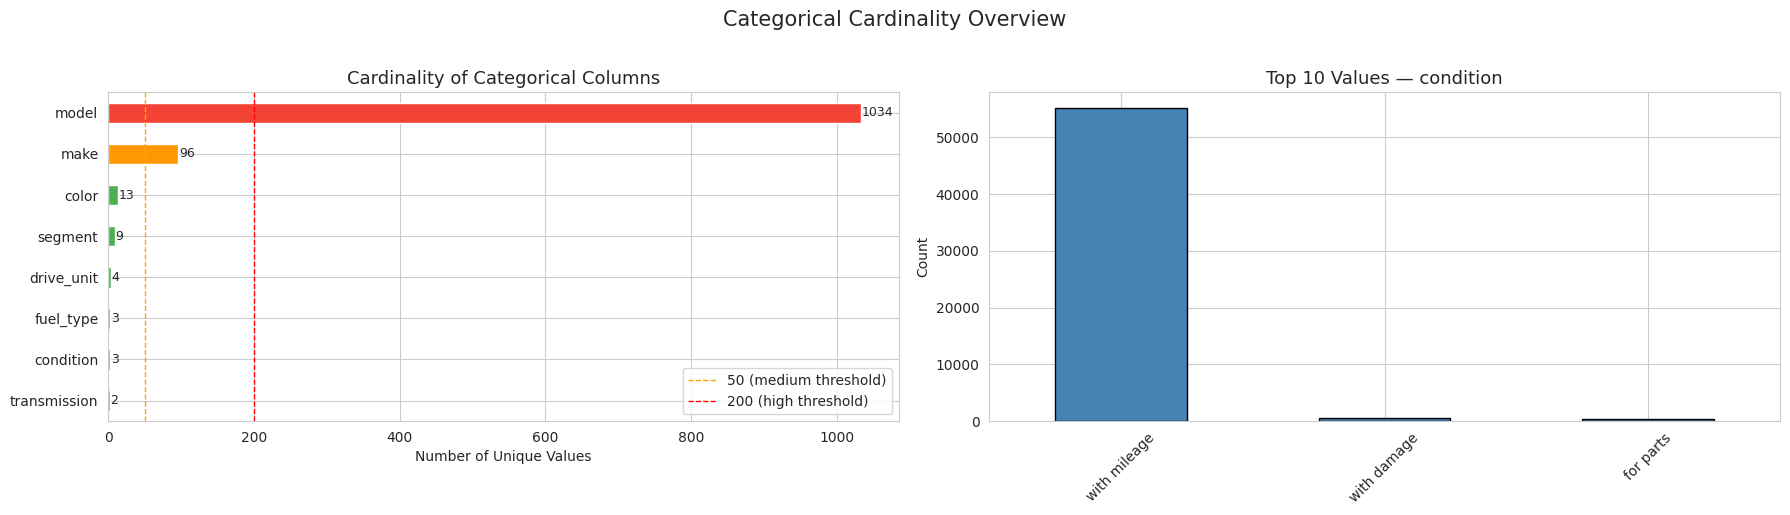


Cardinality Summary:
  Low  cardinality (<= 10 unique)  : 5 columns - safe to encode
  Med  cardinality (11-50 unique)  : 1 columns - safe to encode
  High cardinality (51-200 unique) : 1 columns - consider grouping
  Very high (>200 unique)          : 1 columns - drop or group


In [0]:
# Visualize cardinality for categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cardinality = pd.Series({col: df[col].nunique() for col in cat_cols}).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart — unique values per categorical column
colors = ['#F44336' if v > 200 else '#FF9800' if v > 50 else '#4CAF50' for v in cat_cardinality.values]
cat_cardinality.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Cardinality of Categorical Columns', fontsize=13)
axes[0].set_xlabel('Number of Unique Values')
axes[0].axvline(x=50,  color='orange', linestyle='--', linewidth=1, label='50 (medium threshold)')
axes[0].axvline(x=200, color='red',    linestyle='--', linewidth=1, label='200 (high threshold)')
axes[0].legend()
for i, v in enumerate(cat_cardinality.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# Top 10 most frequent values for the first low-cardinality column
low_card_cols = [c for c in cat_cols if df[c].nunique() <= 20]
if low_card_cols:
    col = low_card_cols[0]
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
    axes[1].set_title(f'Top 10 Values — {col}', fontsize=13)
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Cardinality Overview', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\nCardinality Summary:")
print(f"  Low  cardinality (<= 10 unique)  : {sum(1 for c in cat_cols if df[c].nunique() <= 10)} columns - safe to encode")
print(f"  Med  cardinality (11-50 unique)  : {sum(1 for c in cat_cols if 10 < df[c].nunique() <= 50)} columns - safe to encode")
print(f"  High cardinality (51-200 unique) : {sum(1 for c in cat_cols if 50 < df[c].nunique() <= 200)} columns - consider grouping")
print(f"  Very high (>200 unique)          : {sum(1 for c in cat_cols if df[c].nunique() > 200)} columns - drop or group")

**Insight:**
- Columns with **very high cardinality** (like `model`, `make`) need to be grouped or dropped in feature engineering to avoid extreme sparsity after one-hot encoding
- Columns with **low/medium cardinality** (like `fuel_type`, `transmission`, `color`) are safe to encode directly


## 3. Target Variable Analysis (Price)

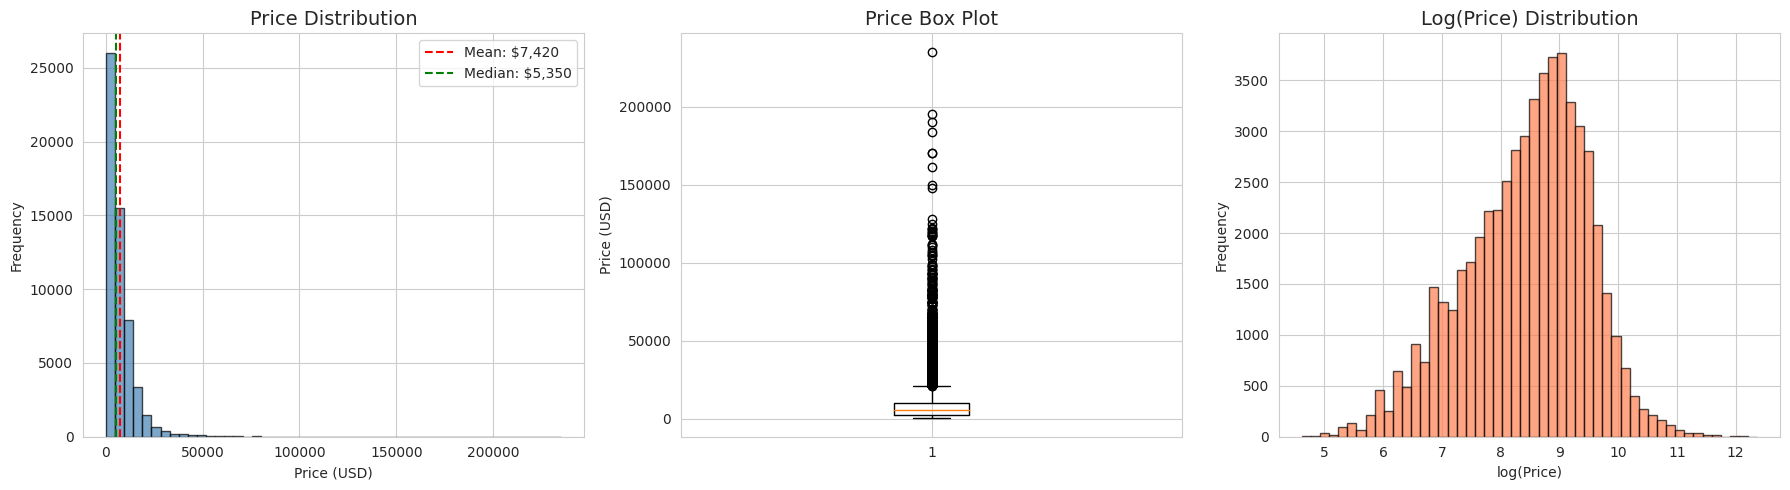

Price Statistics:
count     56133.000000
mean       7420.071152
std        8321.526773
min         100.000000
25%        2350.000000
50%        5350.000000
75%        9850.000000
max      235235.000000

Skewness: 5.14
Kurtosis: 59.56


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['priceUSD'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution', fontsize=14)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['priceUSD'].mean(), color='red', linestyle='--', label=f"Mean: ${df['priceUSD'].mean():,.0f}")
axes[0].axvline(df['priceUSD'].median(), color='green', linestyle='--', label=f"Median: ${df['priceUSD'].median():,.0f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df['priceUSD'], vert=True)
axes[1].set_title('Price Box Plot', fontsize=14)
axes[1].set_ylabel('Price (USD)')

# Log-transformed histogram
axes[2].hist(np.log1p(df['priceUSD']), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_title('Log(Price) Distribution', fontsize=14)
axes[2].set_xlabel('log(Price)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Price Statistics:")
print(df['priceUSD'].describe().to_string())
print(f"\nSkewness: {df['priceUSD'].skew():.2f}")
print(f"Kurtosis: {df['priceUSD'].kurtosis():.2f}")

**Insight:** Price is heavily right-skewed — most cars are priced under $10,000, with a long tail of expensive vehicles. The log-transformed distribution is much closer to normal.

## 3. Price Dist by brand

*Which manufacturers tend to have higher or lower price ranges?*

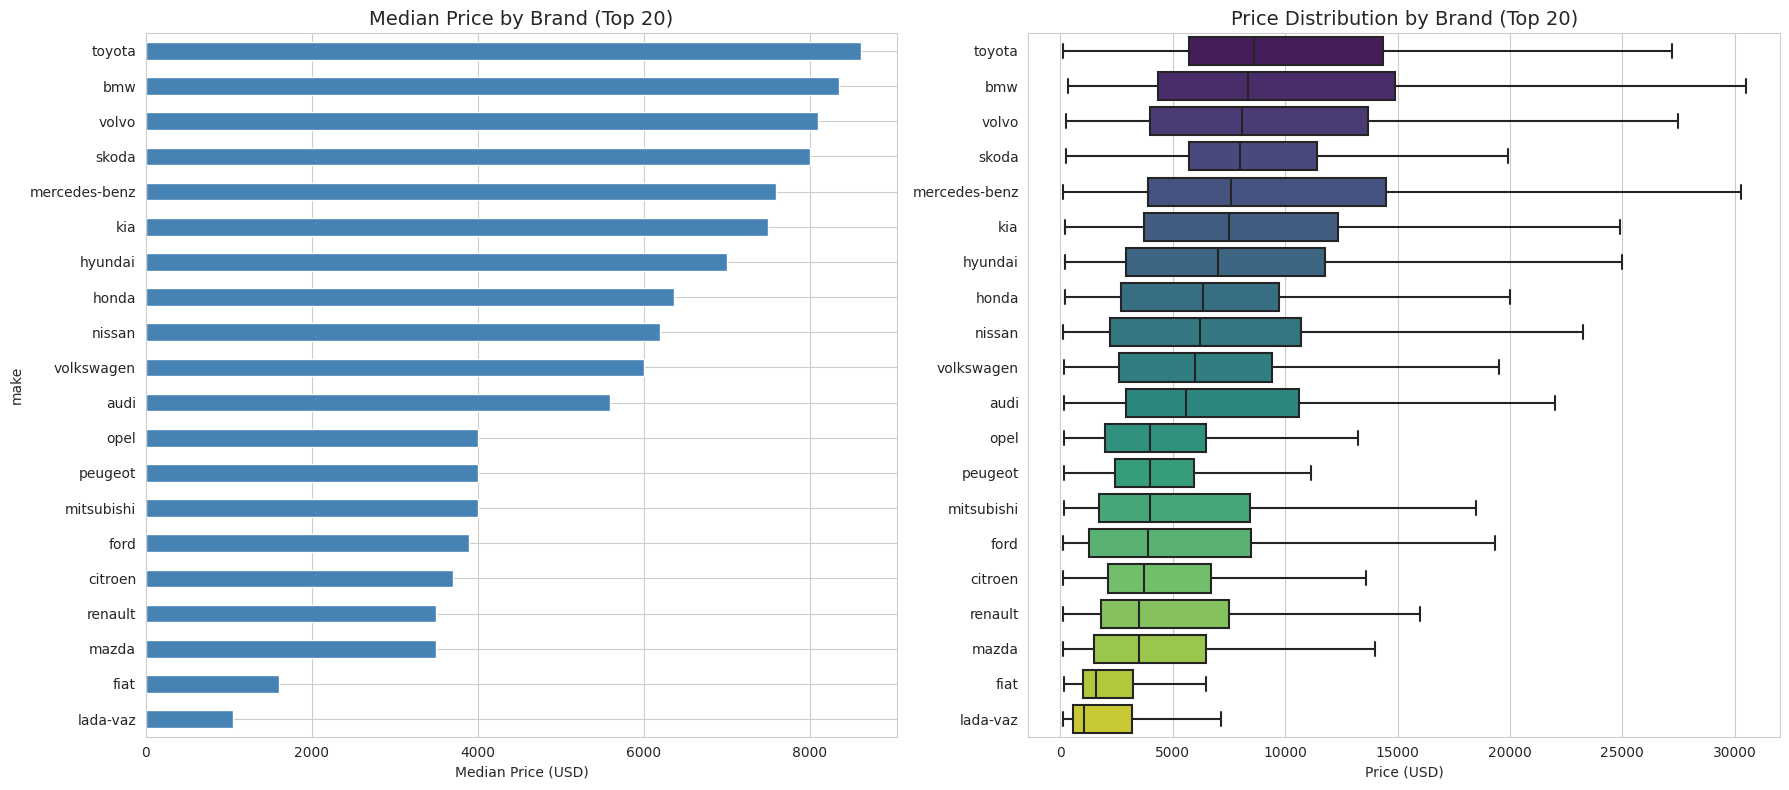

Brand price statistics (top 20 by count):
                       mean  median  count
make                                      
toyota         11495.480239  8625.0   2176
bmw            11392.334831  8350.0   4005
volvo           9791.915516  8100.0   1231
skoda           9125.125219  8000.0   1142
mercedes-benz  11797.502120  7600.0   3537
kia             8506.730769  7500.0   1196
hyundai         8139.115410  7000.0   1499
honda           7216.588608  6360.0    948
nissan          7219.447439  6200.0   2226
volkswagen      6872.084392  6000.0   6849
audi            7846.964624  5600.0   4014
opel            4733.340589  4000.0   3767
peugeot         4698.938285  4000.0   2868
mitsubishi      5983.187082  3999.0   1347
ford            5712.082357  3900.0   3072
citroen         4749.682093  3700.0   1988
renault         4937.370140  3500.0   3704
mazda           4984.584830  3500.0   2004
fiat            2632.112420  1600.0    934
lada-vaz        2698.295295  1046.0    999


In [0]:
top_brands = df['make'].value_counts().head(20).index.tolist()
df_top = df[df['make'].isin(top_brands)]

brand_price = df_top.groupby('make')['priceUSD'].agg(['mean', 'median', 'count']).sort_values('median', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

brand_price['median'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Median Price by Brand (Top 20)', fontsize=14)
axes[0].set_xlabel('Median Price (USD)')

order = brand_price.sort_values('median', ascending=False).index
sns.boxplot(data=df_top, y='make', x='priceUSD', order=order, ax=axes[1], palette='viridis', showfliers=False)
axes[1].set_title('Price Distribution by Brand (Top 20)', fontsize=14)
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Brand price statistics (top 20 by count):")
print(brand_price.sort_values('median', ascending=False).to_string())

**Insight:** Premium brands (BMW, Mercedes-Benz, Volvo) have significantly higher median prices than economy brands (Daewoo, Opel, Renault). Brand is a strong predictor of price.

## 4. Mileage & Depreciation Trends

*How does an increase in mileage impact resale value?*

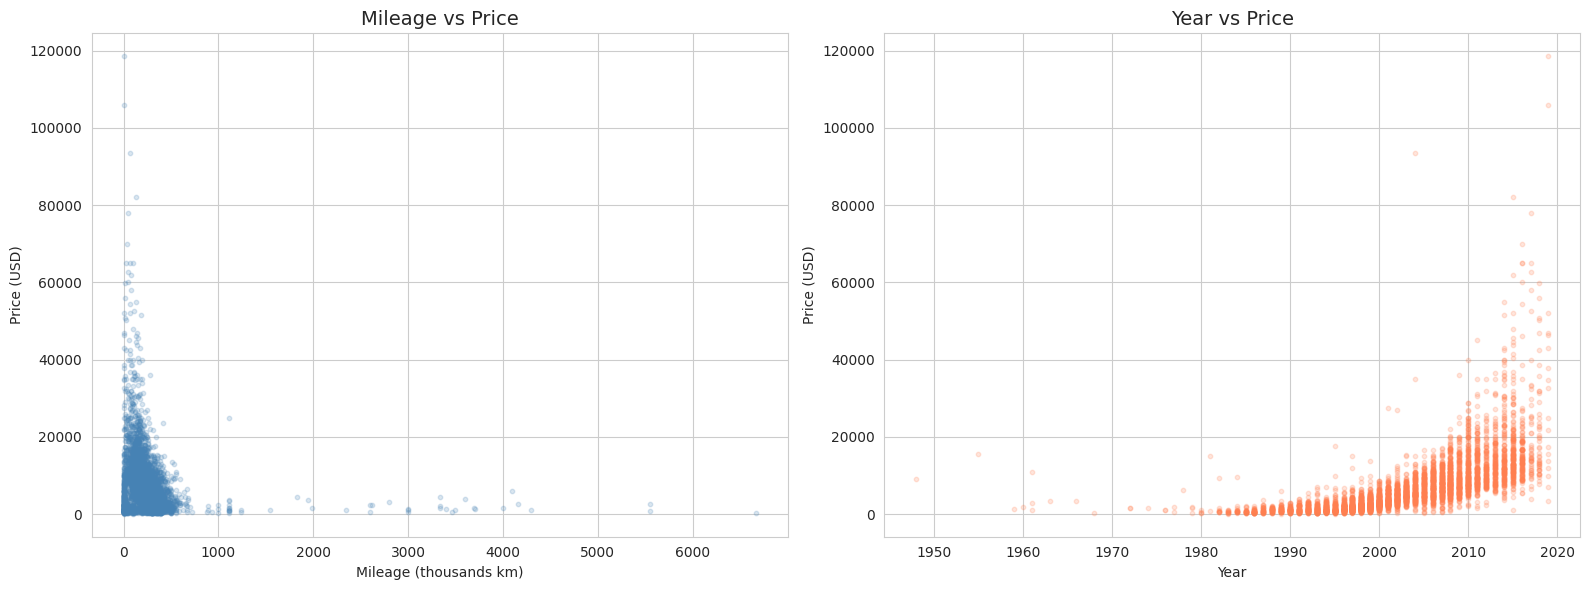

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = df.sample(min(5000, len(df)), random_state=42)

axes[0].scatter(sample['mileage_kilometers'] / 1000, sample['priceUSD'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Mileage vs Price', fontsize=14)
axes[0].set_xlabel('Mileage (thousands km)')
axes[0].set_ylabel('Price (USD)')

axes[1].scatter(sample['year'], sample['priceUSD'], alpha=0.2, s=10, color='coral')
axes[1].set_title('Year vs Price', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

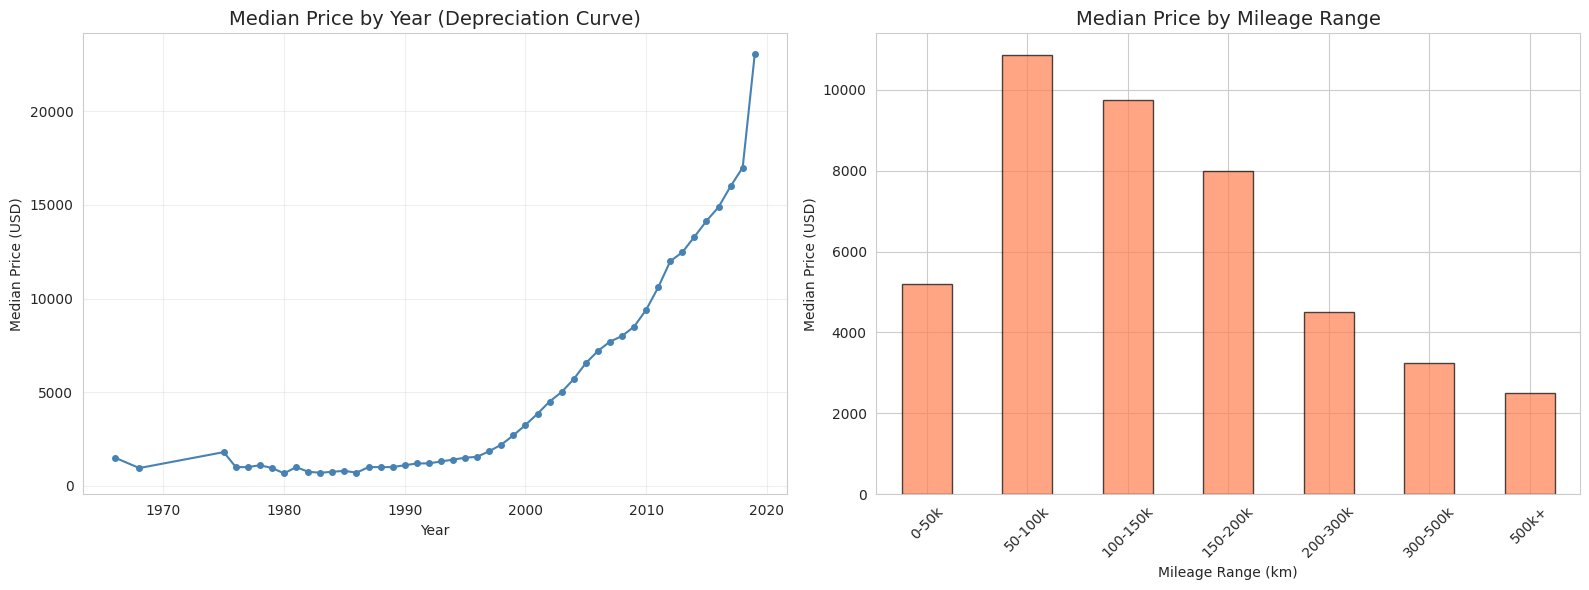

In [0]:
year_price = df.groupby('year')['priceUSD'].agg(['mean', 'median', 'count'])
year_price = year_price[year_price['count'] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(year_price.index, year_price['median'], marker='o', color='steelblue', markersize=4)
axes[0].set_title('Median Price by Year (Depreciation Curve)', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Price (USD)')
axes[0].grid(True, alpha=0.3)

df['mileage_bin'] = pd.cut(df['mileage_kilometers'], bins=[0, 50000, 100000, 150000, 200000, 300000, 500000, 1000000],
                            labels=['0-50k', '50-100k', '100-150k', '150-200k', '200-300k', '300-500k', '500k+'])
mileage_price = df.groupby('mileage_bin', observed=True)['priceUSD'].median()

mileage_price.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Median Price by Mileage Range', fontsize=14)
axes[1].set_xlabel('Mileage Range (km)')
axes[1].set_ylabel('Median Price (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df = df.drop(columns=['mileage_bin'])

**Insight:** Clear depreciation pattern — newer cars and lower-mileage cars command significantly higher prices. Prices rise sharply for cars made after 2005 and drop steadily with increased mileage.

## 5. Car Segments & Price Patterns

*Do luxury cars consistently retain higher values compared to economy models?*

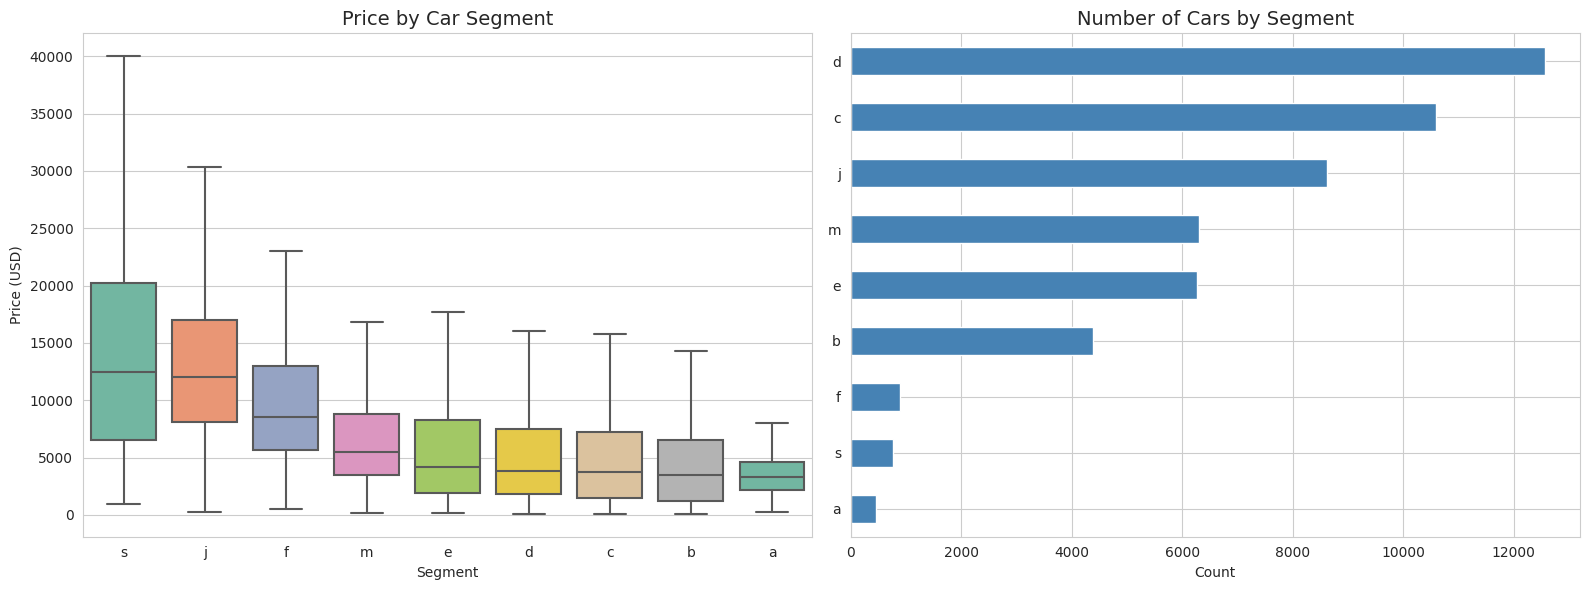

Median price by segment:
segment
s    12500.0
j    12000.0
f     8500.0
m     5500.0
e     4150.0
d     3800.0
c     3750.0
b     3500.0
a     3300.0


In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_order = df.groupby('segment')['priceUSD'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='segment', y='priceUSD', order=segment_order, ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Price by Car Segment', fontsize=14)
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Price (USD)')

df['segment'].value_counts().sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Number of Cars by Segment', fontsize=14)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("Median price by segment:")
print(df.groupby('segment')['priceUSD'].median().sort_values(ascending=False).to_string())

**Insight:** Higher segments (F, E, S) command premium prices, while economy segments (A, B) are significantly cheaper. The segment feature captures a meaningful price hierarchy.

## 6. Correlation Analysis

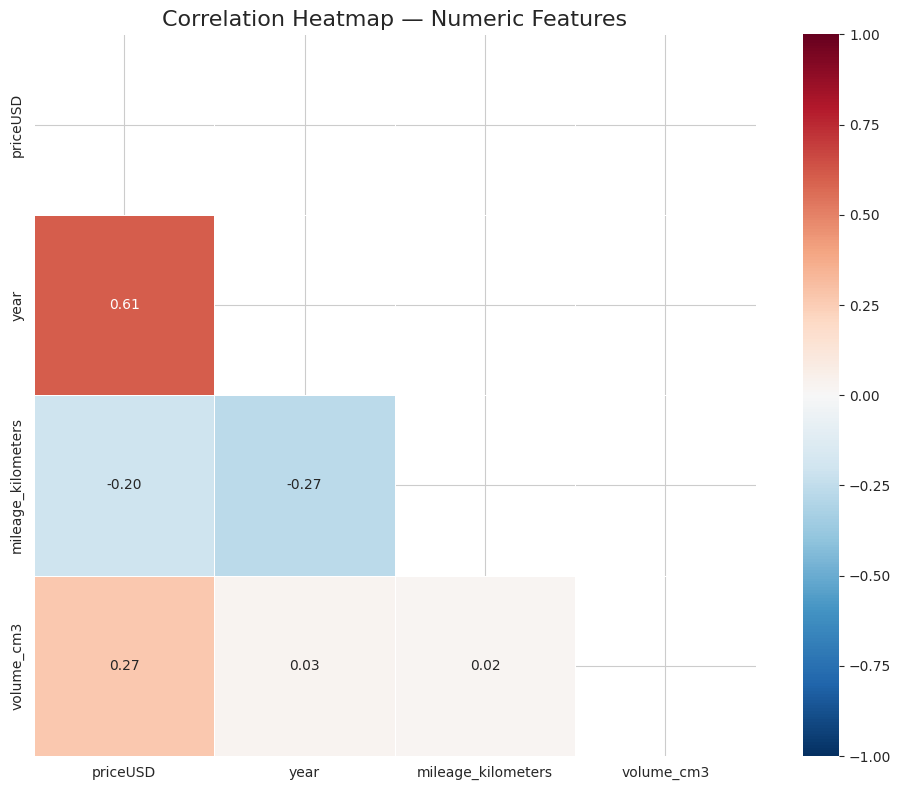

Correlations with price:
year                  0.605419
volume_cm3            0.267520
mileage_kilometers   -0.203686


In [0]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

price_corr = corr_matrix['priceUSD'].drop('priceUSD').sort_values(ascending=False)
print("Correlations with price:")
print(price_corr.to_string())

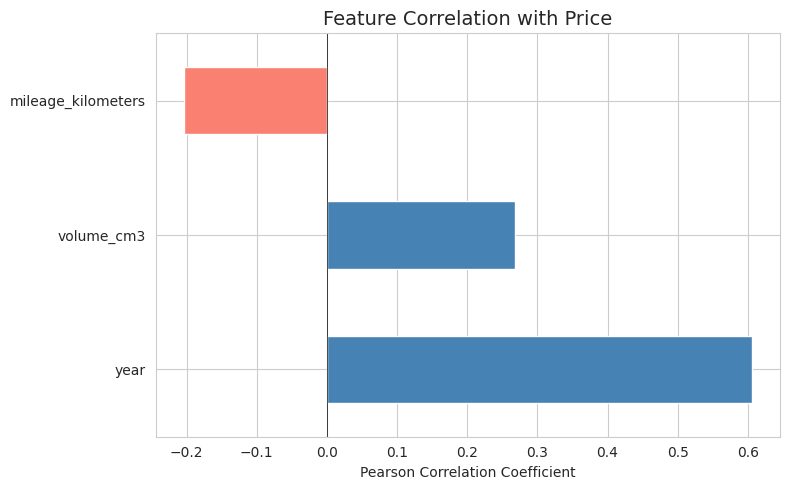

In [0]:
plt.figure(figsize=(8, 5))
colors = ['steelblue' if x > 0 else 'salmon' for x in price_corr.values]
price_corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Price', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

**Insight:** `year` has the strongest positive correlation with price (newer = more expensive). `mileage_km` has a negative correlation (higher mileage = cheaper). `volume_cm3` is moderately positive (bigger engines = higher prices).

## 7. Categorical Features vs Price

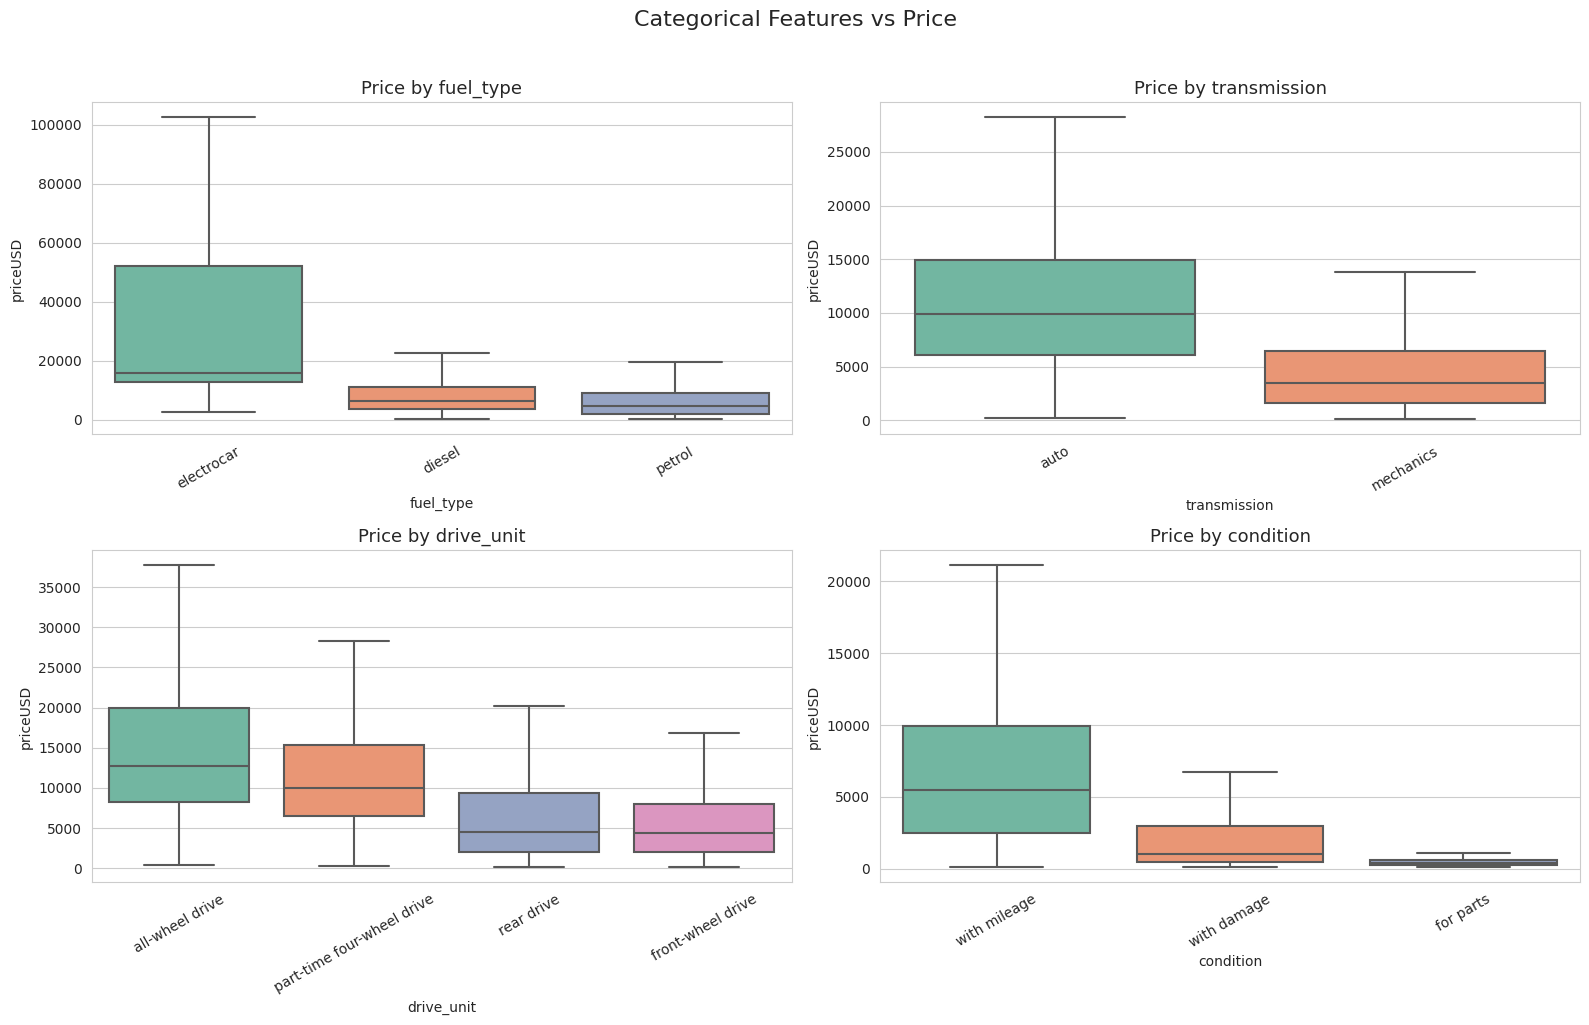

In [0]:
cat_features = ['fuel_type', 'transmission', 'drive_unit', 'condition']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    order = df.groupby(feat)['priceUSD'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feat, y='priceUSD', order=order, ax=axes[i], palette='Set2', showfliers=False)
    axes[i].set_title(f'Price by {feat}', fontsize=13)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features vs Price', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

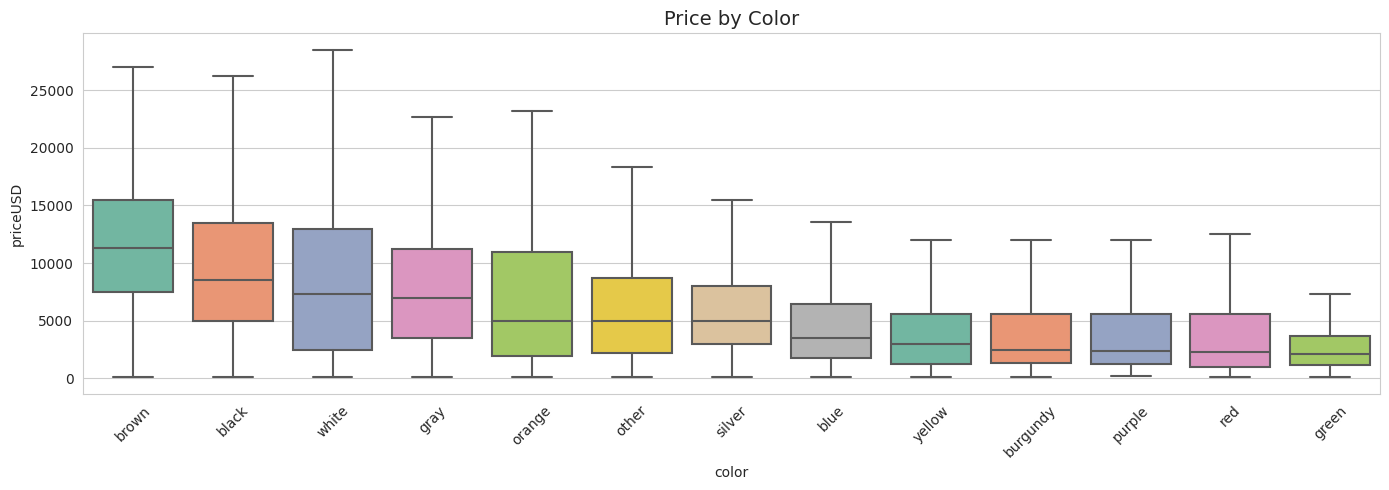

In [0]:
plt.figure(figsize=(14, 5))
color_order = df.groupby('color')['priceUSD'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='color', y='priceUSD', order=color_order, palette='Set2', showfliers=False)
plt.title('Price by Color', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**
- **Fuel type:** Diesel cars tend to be priced higher than petrol
- **Transmission:** Automatic cars are generally pricier than manual
- **Drive unit:** All-wheel/4WD vehicles command higher prices
- **Condition:** Cars 'with mileage' are priced higher than damaged/for-parts vehicles

## 8. Numeric Feature Distributions

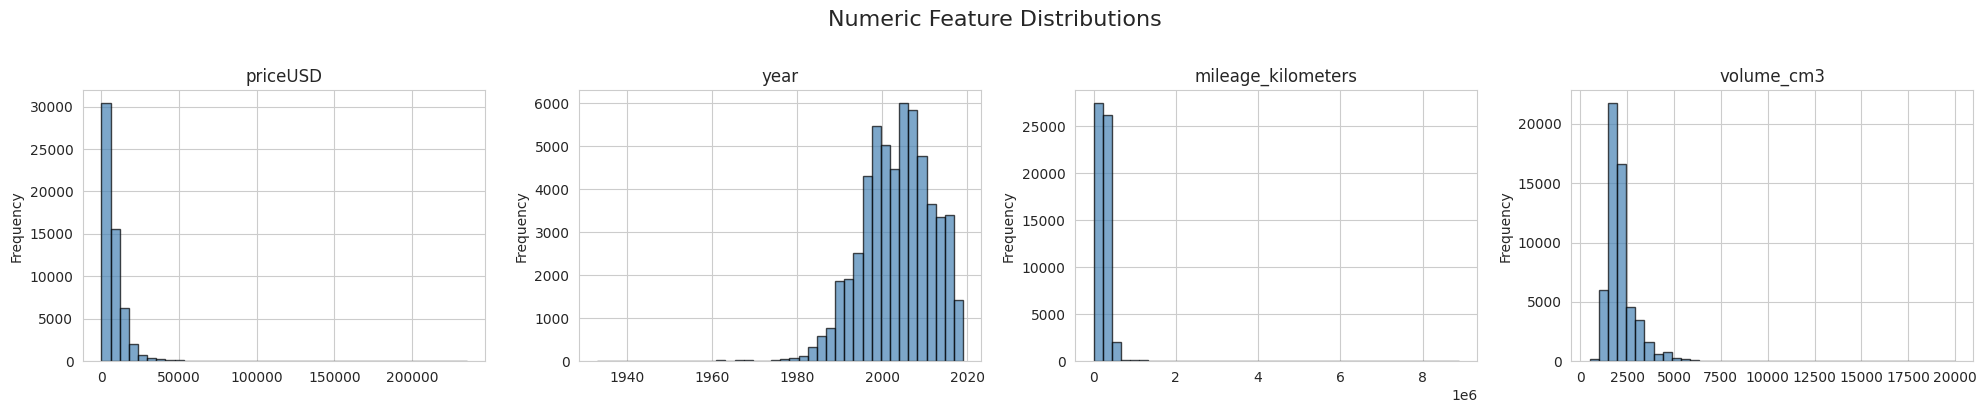

In [0]:
numeric_features = [c for c in numeric_cols if c != 'price']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(5 * len(numeric_features), 4))
if len(numeric_features) == 1:
    axes = [axes]

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numeric Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary of Key EDA Findings

| Finding | Details |
|---------|--------|
| **Cardinality** | `model` (very high — dropped), `make` (high — grouped), `fuel_type`, `transmission`, `color` are low/medium — safe to encode |
| **Target (price)** | Heavily right-skewed. Most cars under $10,000. Mean > Median. |
| **Brand influence** | Premium brands (BMW, Mercedes, Volvo) have 2-3x higher median prices than economy brands |
| **Mileage & depreciation** | Clear negative relationship — higher mileage = lower price |
| **Year & depreciation** | Strong positive correlation — newer cars command higher prices |
| **Segments** | Higher segments (E, F, S) = higher prices |
| **Transmission** | Automatic cars priced higher on average |
| **Drive unit** | AWD/4WD vehicles command premium prices |
| **Engine volume** | Moderate positive correlation with price |

### Actions for Feature Engineering (Notebook 4):
1. Create `car_age` = 2019 - year
2. Create `mileage_per_year` = mileage / car_age
3. Group rare makes into `make_category` to reduce cardinality
4. Create `price_category` for stratified split
5. Drop `model` (very high cardinality — too sparse for encoding)
6. Drop `year` and `make` (replaced by engineered features)